<a href="https://colab.research.google.com/github/tojotk/IMDb_Movie_Reviews/blob/main/IMDb_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Read dataset

In [4]:
df_movie = pd.read_csv('/content/drive/MyDrive/AI ML Course/Data/IMDB Dataset.csv')
df_movie.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# EDA

In [5]:
df_movie.shape

(50000, 2)

In [6]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df_movie.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
df_movie.isnull().sum()

,0
review,0
sentiment,0


In [9]:
# view sentiment distrubution
df_movie["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Plot Visulaization

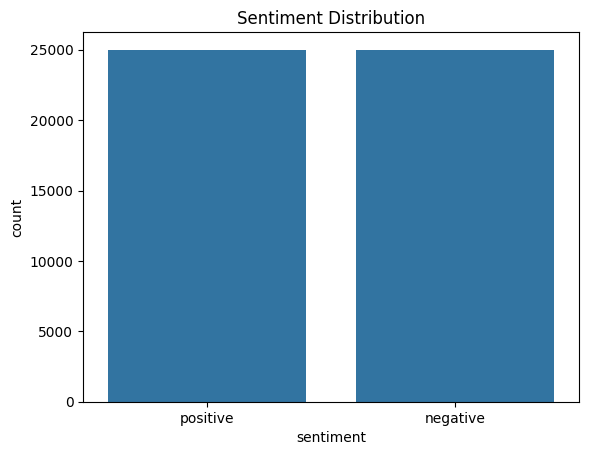

In [11]:
# Draw bar chart
sns.countplot(x="sentiment", data=df_movie)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
# Checking review length

In [12]:
# Count number of words in each review
df_movie["Review_Length"] = df_movie["review"].apply(lambda x: len(x.split()))
df_movie["Review_Length"].head()

,Review_Length
0,307
1,162
2,166
3,138
4,230


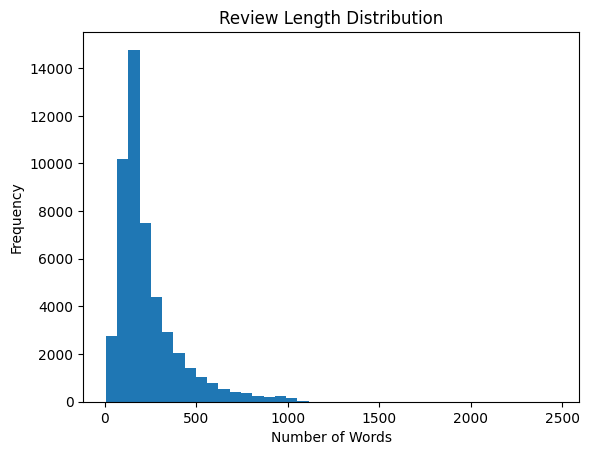

In [13]:
# Plot histogram
plt.hist(df_movie["Review_Length"], bins=40)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")

plt.show()

# Text Preprocessing

## Duplicates removal

In [16]:
df_movie.duplicated().sum()

np.int64(418)

In [17]:
df_movie.drop_duplicates(inplace=True)

In [18]:
df_movie.duplicated().sum()

np.int64(0)

## Missing value

In [19]:
df_movie.isnull().sum()

,0
review,0
sentiment,0
Review_Length,0


## Remove html tags

In [20]:
# Function to remove HTML tags
def remove_html(text):
    clean = re.compile("<.*?>")
    return re.sub(clean, "", text)
df_movie["review"] = df_movie["review"].apply(remove_html)

## Convert to lowercase

In [21]:
# Convert all text into lowercase
df_movie["review"] = df_movie["review"].str.lower()

## Remove Punctuations

In [22]:
# Function to remove punctuation
def remove_punctuation(text):
    # Remove punctuation characters
    return text.translate(str.maketrans("", "", string.punctuation))
df_movie["review"] = df_movie["review"].apply(remove_punctuation)

## Tokenazation

In [27]:
# Convert sentence into list of words
df_movie["Tokens"] = df_movie["review"].apply(word_tokenize)
# Display first review tokens
df_movie["Tokens"].head()

,Tokens
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."


## Remove Stopwords

In [29]:
# Load  stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords
df_movie["Tokens"] = df_movie["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

## Stemming

In [30]:
# Create stemmer object
stemmer = PorterStemmer()

# Apply stemming
df_movie["Stemmed"] = df_movie["Tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

## Lemmatization

In [31]:
# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_movie["Lemmatized"] = df_movie["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

## Convert tokens back to sentence

In [32]:
# Join words into a sentence
df_movie["Clean_Review"] = df_movie["Lemmatized"].apply(lambda words: " ".join(words))

# Display cleaned reviews
df_movie[["review", "Clean_Review"]].head()

,review,Clean_Review
0,one of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


In [33]:
df_movie.head()

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,positive,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,positive,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,negative,138,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,positive,230,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...
